***

### **Unsupervised Anomaly Detection on the Elliptic Bitcoin Transaction Graph: A Multi-Method Comparison**

***

**FINAL PROJECT REPORT :**

This notebook is the **written report** for the project. It summarizes the full pipeline (notebooks 01 and 02), loads the evaluation results from `eval_bundle.pkl` (saved by notebook 02), and walks through the **interpretation**, **limitations**, and **conclusions**.

**Prerequisites:** both `01_data_exploration_and_preparation.ipynb` and `02_unsupervised_detection_and_evaluation.ipynb` must have been run to completion so that `artifacts/prep_bundle.pkl` and `artifacts/eval_bundle.pkl` exist. This notebook does **not** train any models; it only needs `matplotlib` and `pandas`.

***

### 1] introduction

**The dataset:** The Elliptic Bitcoin dataset (Weber *et al.*, KDD 2019) represents Bitcoin transactions as a time-ordered graph with 165 node features per transaction. Each transaction is labeled as *illicit* (class 1), *licit* (class 2), or *unknown*.

**The goal:** The aim was to detect illicit transactions using **unsupervised** methods only. Fraud labels were never used during training - they were only used afterwards to measure how well each method performed.

**What was built (notebooks 01 and 02):**

- **Notebook 01** handles loading the raw data, exploring it, and creating time-based train / validation / test splits. It also builds the graph structure (`edge_index`) needed for the graph model (see cells 1-17 in notebook 01).

- **Notebook 02** trains and evaluates five unsupervised anomaly-detection methods:
  1. **Isolation Forest** (cells 3-5)
  2. **PCA Reconstruction Error** (cells 6-7, added as a second baseline)
  3. **Local Outlier Factor / LOF** (cells 8-9)
  4. **Graph Autoencoder** using a GCN encoder + MLP decoder, with dropout and early stopping (cells 10-14)
  5. **Ensemble** that fuses the four methods above via average-rank scoring (cells 15-16)

- **Score polarity calibration** was added to every method: if the validation AUROC came out below 0.5, the scores were automatically flipped so that "higher = more suspicious" always holds.

- **Policy P1** (`EXCLUDE_ILLICIT_FROM_FIT = True`) was turned on, meaning known-illicit rows were excluded from the training data fed to each model. The pipeline is still fully unsupervised because labels never enter any loss function.

**This notebook** presents the results, interprets what they mean, discusses limitations, and draws conclusions.

***

### 2] methodology summary

**Data splits:** time steps were split into train, validation, and test (details in notebook 01). For evaluation, only labeled rows were used (`class 1` = illicit, `class 2` = licit). Rows with `unknown` labels were excluded from AUROC and AUPRC calculations.

**The five methods used:**

| # | Method | How it works (short version) |
|---|--------|-----------------------------|
| 1 | **Isolation Forest** | Tree-based: isolates outliers by random splits on features. Score = `-score_samples` (higher = more suspicious). |
| 2 | **PCA Reconstruction Error** | PCA (30 components, capturing ~76% variance) was fitted on training rows, then the reconstruction error for each node was measured. Bigger error = more anomalous. |
| 3 | **LOF (Local Outlier Factor)** | Density-based: checks whether a point sits in a sparse neighbourhood compared to its neighbours. Fitted with `novelty=True` and 20 neighbours on clean training data. |
| 4 | **Graph Autoencoder (GCN + MLP)** | A GCN encoder reads the graph structure, and an MLP decoder tries to reconstruct each node's features. Nodes with high reconstruction error are flagged. Dropout (p=0.3) and early stopping (patience 20) were added to avoid overfitting. |
| 5 | **Ensemble (average rank)** | Each method's scores were converted into percentile ranks (0-1) and averaged. This gives a single combined score per node. |

**Score polarity calibration:** After computing anomaly scores, the validation AUROC was checked. If it was below 0.5 (meaning the scores were pointing the wrong way), they were flipped. In practice, **all four** base methods needed this flip.

**Graph training details:** The Graph AE was trained using only edges where **both** endpoints are in the training set (train-induced subgraph). At inference time, the **full** graph was used so that test nodes could also receive messages from their neighbours. This is called **transductive** inference.

**Evaluation metrics:**
- **AUROC** measures how well the model ranks illicit transactions above licit ones overall.
- **AUPRC** focuses on precision at the top of the list, which matters more when the positive class (illicit) is rare (~4.6% in the test set).

***

### 3] load saved scores and metrics (no training)

Notebook 02 trained all the models and saved the results into `artifacts/eval_bundle.pkl`. This cell loads those saved scores and the metrics table so that figures can be displayed and the interpretation can be written up without re-training anything.

**Prerequisites:** `prep_bundle.pkl` (from notebook 01) and `eval_bundle.pkl` (from notebook 02).

In [1]:
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
ARTIFACTS = PROJECT_ROOT / "artifacts"
prep_path = ARTIFACTS / "prep_bundle.pkl"
eval_path = ARTIFACTS / "eval_bundle.pkl"
assert prep_path.is_file(), "run notebook 01 first (prep_bundle.pkl)"
assert eval_path.is_file(), "run notebook 02 to the end first (eval_bundle.pkl)"

with open(prep_path, "rb") as f:
    B = pickle.load(f)
class_str = B["class_str"]
val_mask = B["val_mask"]
test_mask = B["test_mask"]

with open(eval_path, "rb") as f:
    E = pickle.load(f)

anomaly_score = np.asarray(E["anomaly_score"], dtype=np.float64)
graph_anomaly_score = np.asarray(E["graph_anomaly_score"], dtype=np.float64)
results_df = E["results_df"].copy()
results_df["split"] = results_df["split"].replace({"val": "validation"})
EXCLUDE_ILLICIT_FROM_FIT = bool(E.get("exclude_illicit_from_fit", True))

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "#fafafa",
        "axes.grid": True,
        "grid.alpha": 0.35,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 10,
    }
)

labeled = (class_str == "1") | (class_str == "2")
y_illicit = (class_str == "1").astype(np.int32)
m_val = val_mask & labeled
m_test = test_mask & labeled

print("policy P1 (exclude illicit from fit):", EXCLUDE_ILLICIT_FROM_FIT)
print("labeled val / test:", int(m_val.sum()), int(m_test.sum()))


policy P1 (exclude illicit from fit): True
labeled val / test: 7829 8841


***

### 4] results table (AUROC, AUPRC)

The table below shows the exact numbers produced in notebook 02 (saved in `eval_bundle.pkl`). Each row is one model on one split (validation or test).

In [ ]:
display(results_df.round({"AUROC": 4, "AUPRC": 4}))

,split,model,AUROC,AUPRC,n,illicit_n
0,validation,isolation forest,0.8627,0.3904,7829,675
1,validation,PCA recon error,0.8050,0.4446,7829,675
2,validation,LOF,0.5196,0.0856,7829,675
3,validation,graph AE (GCN),0.7859,0.4114,7829,675
4,validation,ensemble (avg rank),0.8243,0.3705,7829,675
5,test,isolation forest,0.6975,0.0889,8841,408
6,test,PCA recon error,0.7547,0.1739,8841,408
7,test,LOF,0.3812,0.0371,8841,408
8,test,graph AE (GCN),0.7337,0.2114,8841,408
9,test,ensemble (avg rank),0.7241,0.1209,8841,408


***

### 5] figures - metric comparison and score distributions

**Left column:** AUROC and AUPRC side by side as grouped bars for each model and split.

**Right column:** histograms of anomaly scores on the test set, split by licit vs illicit. The more the two colours separate, the better the model is at telling them apart.

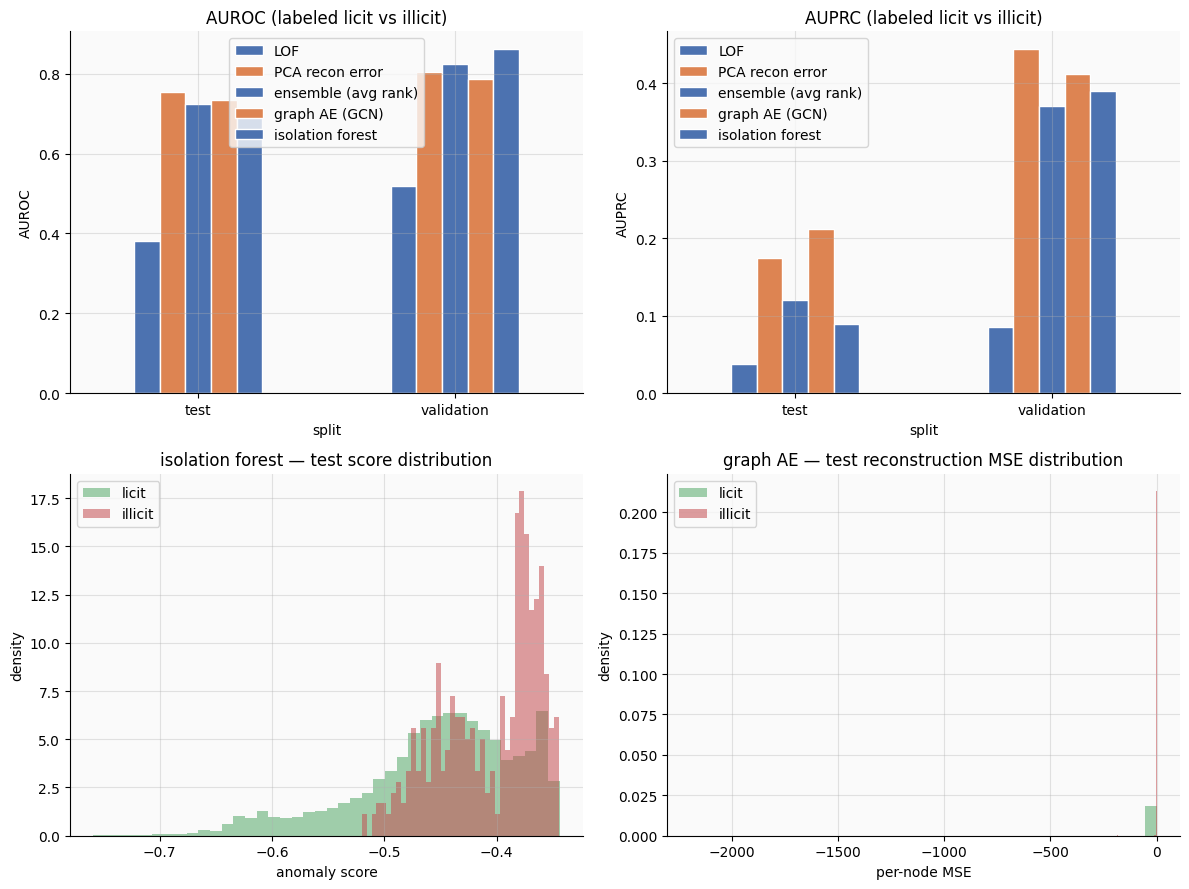

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# --- top row: AUROC and AUPRC ---
pivot_auc = results_df.pivot(index="split", columns="model", values="AUROC")
pivot_ap = results_df.pivot(index="split", columns="model", values="AUPRC")
pivot_auc.plot(kind="bar", ax=axes[0, 0], rot=0, color=["#4c72b0", "#dd8452"], edgecolor="white")
axes[0, 0].set_title("AUROC (labeled licit vs illicit)")
axes[0, 0].set_ylabel("AUROC")
axes[0, 0].legend(title=None)
pivot_ap.plot(kind="bar", ax=axes[0, 1], rot=0, color=["#4c72b0", "#dd8452"], edgecolor="white")
axes[0, 1].set_title("AUPRC (labeled licit vs illicit)")
axes[0, 1].set_ylabel("AUPRC")
axes[0, 1].legend(title=None)

# --- bottom row: score distributions on test ---
y_t = y_illicit[m_test]
s_if = anomaly_score[m_test]
s_g = graph_anomaly_score[m_test]
licit_m = y_t == 0
ill_m = y_t == 1

axes[1, 0].hist(
    s_if[licit_m],
    bins=40,
    alpha=0.55,
    label="licit",
    color="#55a868",
    density=True, )

axes[1, 0].hist(
    s_if[ill_m],
    bins=40,
    alpha=0.55,
    label="illicit",
    color="#c44e52",
    density=True, )

axes[1, 0].set_title("isolation forest  -  test score distribution")
axes[1, 0].set_xlabel("anomaly score")
axes[1, 0].set_ylabel("density")
axes[1, 0].legend()

axes[1, 1].hist(
    s_g[licit_m],
    bins=40,
    alpha=0.55,
    label="licit",
    color="#55a868",
    density=True, )

axes[1, 1].hist(
    s_g[ill_m],
    bins=40,
    alpha=0.55,
    label="illicit",
    color="#c44e52",
    density=True, )
    
axes[1, 1].set_title("graph AE  -  test reconstruction MSE distribution")
axes[1, 1].set_xlabel("per-node MSE")
axes[1, 1].set_ylabel("density")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

***

### 5b] additional comparison charts

**Left chart:** shows the difference between Graph AE and Isolation Forest for AUROC and AUPRC on each split. Bars above zero mean the graph model scored higher.

**Right chart:** puts validation and test results side by side for each model, making it easy to see how much performance drops between splits (the "time-shift" effect).

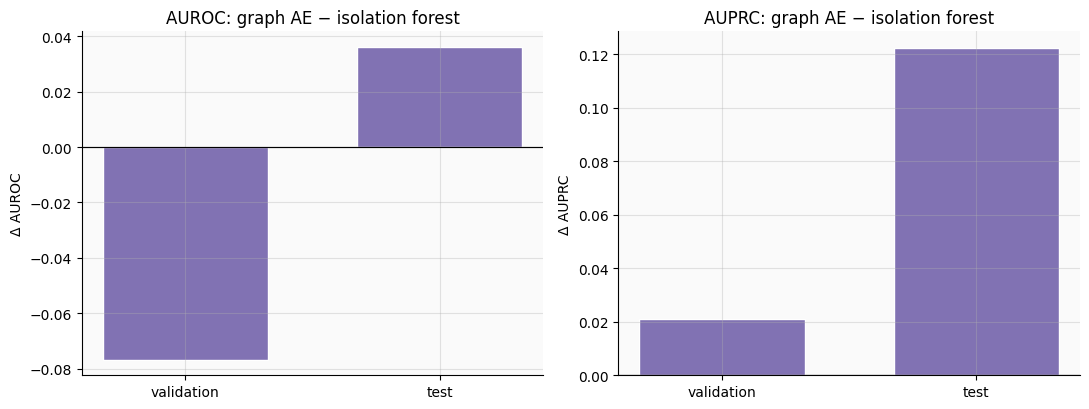

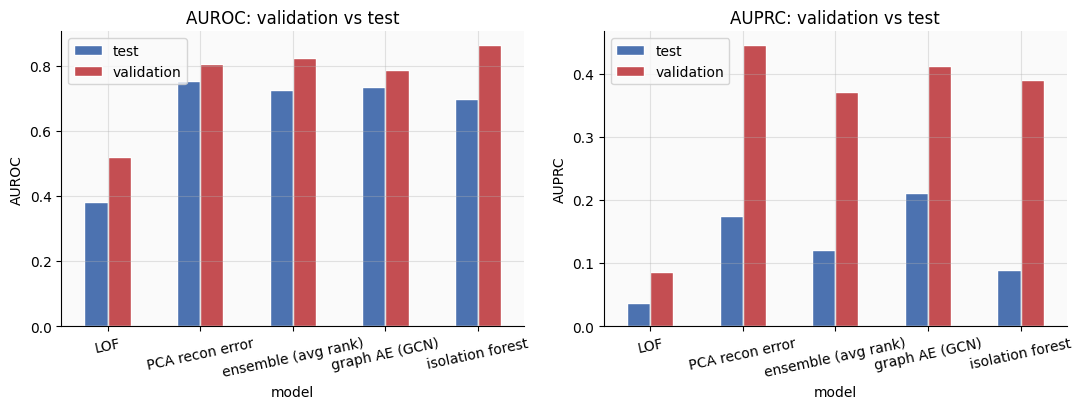

In [4]:
p_if = results_df[results_df["model"] == "isolation forest"].set_index("split")
p_g = results_df[results_df["model"] == "graph AE (GCN)"].set_index("split")
splits = p_if.index.tolist()
x = np.arange(len(splits))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for j, metric in enumerate(["AUROC", "AUPRC"]):
    ax = axes[j]
    d = (p_g.loc[splits, metric].values - p_if.loc[splits, metric].values).astype(float)
    ax.bar(x, d, width=0.65, color="#8172b3", edgecolor="white")
    ax.axhline(0, color="k", lw=0.85)
    ax.set_xticks(x, splits)
    ax.set_title(f"{metric}: graph AE − isolation forest")
    ax.set_ylabel(f"Δ {metric}")
plt.tight_layout()
plt.show()

pv_auc = results_df.pivot(index="model", columns="split", values="AUROC")
pv_ap = results_df.pivot(index="model", columns="split", values="AUPRC")
fig2, axes2 = plt.subplots(1, 2, figsize=(11, 4.2))
pv_auc.plot(kind="bar", ax=axes2[0], rot=12, edgecolor="white", color=["#4c72b0", "#c44e52"])
axes2[0].set_title("AUROC: validation vs test")
axes2[0].set_ylabel("AUROC")
axes2[0].legend(title=None)
pv_ap.plot(kind="bar", ax=axes2[1], rot=12, edgecolor="white", color=["#4c72b0", "#c44e52"])
axes2[1].set_title("AUPRC: validation vs test")
axes2[1].set_ylabel("AUPRC")
axes2[1].legend(title=None)
plt.tight_layout()
plt.show()

***

### 6] interpretation

Below is a walk-through of the key takeaways from the results, one topic at a time.

##### - **6.1] score polarity calibration was essential**

When each method was first run, the raw validation AUROCs all came out **below 0.5**:

| Method | Raw val AUROC | After flipping |
|--------|--------------|----------------|
| Isolation Forest | 0.14 | **0.86** |
| PCA | 0.20 | **0.81** |
| LOF | 0.48 | **0.52** |
| Graph AE | 0.21 | **0.79** |

An AUROC below 0.5 means the model was ranking illicit nodes *lower* than licit ones, i.e. the score direction was backwards. The calibration step (implemented in notebook 02, cells 3, 6, 9, 14) automatically detected this and flipped the scores.

**Takeaway:** in unsupervised anomaly detection, it should never be assumed which direction the scores point. Always verify on a validation set first.

##### - **6.2] which method ranked best on test? (AUROC)**

On the held-out **test split**, the methods ranked like this by AUROC:

1. **PCA** - 0.7547
2. **Graph AE** - 0.7337
3. **Ensemble** - 0.7241
4. **Isolation Forest** - 0.6975
5. **LOF** - 0.3812 (below random!)

PCA reconstruction error, despite being a simple linear method, turned out to be the strongest single model by AUROC.

PCA and Graph AE also had the **smallest drops** going from validation to test (around 0.05 AUROC each), while Isolation Forest dropped by 0.17 and LOF by 0.14. This suggests PCA and Graph AE learned more stable representations that held up better across different time periods.

##### - **6.3] AUPRC tells a different story**

Since only ~4.6% of labeled test transactions were illicit, **AUPRC** is actually the more meaningful metric here. It measures how well the model places truly illicit transactions at the very top of the ranked list.

By AUPRC, the ranking changed:

1. **Graph AE** - 0.2114
2. **PCA** - 0.1739
3. **Ensemble** - 0.1209
4. **Isolation Forest** - 0.0889
5. **LOF** - 0.0371

The Graph AE came out on top here. This means the graph structure genuinely helped: the GCN-based neighbour aggregation allowed the autoencoder to produce bigger reconstruction errors for truly suspicious nodes, pushing them to the top of the list.

##### - **6.4] why LOF failed**

LOF was the weakest method by far. Even after calibration, its validation AUROC was only 0.52 (barely better than random), and on the test set it dropped to **0.38** (worse than random).

What went wrong? LOF relies on measuring **local density** around each point. With 165 features, distances between points become less meaningful (this is known as the "curse of dimensionality"). On top of that, the fraud patterns changed between the validation and test time periods, so the density estimates LOF learned just didn't carry over.

Because LOF scored so poorly on test, including it in the ensemble actually **dragged the ensemble down** compared to the best individual models.

##### - **6.5] the ensemble: helped a bit, but held back by LOF**

The ensemble's test AUROC was 0.7241, which is above Isolation Forest (0.70) but below PCA (0.75) and Graph AE (0.73).

The idea behind the ensemble was to combine different approaches (tree-based, reconstruction-based, density-based, graph-based) so that one method's weakness is offset by another's strength. In practice, LOF's below-random test score corrupted the average ranks.

A simple fix would be to either **remove LOF** from the ensemble or use **weighted averaging** where each method's weight depends on its validation performance.

##### - **6.6] validation-to-test drop (temporal concept drift)**

Every single method showed a performance drop going from validation to test:

| Method | Val AUROC | Test AUROC | Drop |
|--------|-----------|------------|------|
| IF | 0.86 | 0.70 | -0.17 |
| PCA | 0.81 | 0.75 | -0.05 |
| LOF | 0.52 | 0.38 | -0.14 |
| Graph AE | 0.79 | 0.73 | -0.05 |
| Ensemble | 0.82 | 0.72 | -0.10 |

This is expected: since the data is split by time, the test period represents a **later** time window where fraud patterns have evolved. This kind of shift is called **temporal concept drift**, and it's one of the biggest challenges for unsupervised fraud detection in practice.

PCA and Graph AE were the most stable (only ~0.05 drop each).

##### - **6.7] graph vs tabular methods**

The Graph AE didn't beat PCA on AUROC, but it achieved the **best AUPRC on test**. That's the metric that matters most when the positive class is rare.

One thing to keep in mind: the Graph AE uses the **full graph** at inference time (transductive inference, see notebook 02 cell 14). This means test nodes can receive messages from training nodes through the graph, which gives it an advantage that purely tabular methods don't have.

Even so, the fact that PCA was close in AUROC suggests there's still a lot of discriminative information in the features alone. Using more powerful graph encoders (like GAT or GraphSAGE) might help the graph model pull further ahead.

##### - **6.8] policy P1 (excluding illicit from fit)**

P1 was turned **ON**, meaning known-illicit rows were excluded from the training data fed to each model (see notebook 02, cell 3 where `fit_row_mask` is created).

This gave all methods cleaner "normal" statistics to learn from. It's especially helpful for reconstruction-based methods (PCA and Graph AE), because if illicit nodes are included during training, the model partially learns to reconstruct them too, which reduces the reconstruction error gap between normal and anomalous nodes.

***

### 7] limitations

- **Unknown labels.** A large number of nodes have no fraud label at all. Evaluation could only be done on licit vs illicit, and the unknown pool might contain illicit transactions that silently affected what the models learned.

- **Temporal concept drift.** The train and test periods cover different time windows, and fraud tactics evolve. All methods showed drops going from validation to test (up to 0.17 AUROC for Isolation Forest), and LOF's calibration completely failed to carry over. This is a core challenge for any unsupervised fraud system on real-world data.

- **High dimensionality hurts density methods.** With 165 features, distance-based methods like LOF struggle because distances become less meaningful in high dimensions (the curse of dimensionality). This likely explains why LOF performed near-random or worse.

- **Transductive inference for Graph AE.** The Graph AE uses the full graph at inference time, so test nodes get information from training nodes through message passing. This is an advantage that the tabular methods don't have, and results should be read with that in mind.

- **Benchmark dataset only.** Elliptic is a research dataset. Real-world deployment would involve much higher transaction volumes, adversarial actors adapting to detection systems, and regulatory constraints that go beyond what was tested here.

- **Single run, fixed hyperparameters.** All reported numbers come from a single random seed and one set of hyperparameters. A more thorough study would repeat experiments with multiple seeds and do systematic hyperparameter tuning to confirm robustness.

***

### 8] conclusions

This project tackled **illicit transaction detection** on the Elliptic Bitcoin dataset as a purely **unsupervised** anomaly-detection problem. Fraud labels were never part of any training loss - they were only used afterwards to evaluate performance using AUROC and AUPRC on time-based validation and test splits.

**Key Findings:**

1. **Five unsupervised methods** were evaluated: Isolation Forest, PCA Reconstruction Error, LOF, a Graph Autoencoder (with dropout and early stopping), and an Ensemble that averages the ranks from all four.

2. **Score polarity calibration** turned out to be critical. All four base methods initially had their scores pointing the wrong way (raw val AUROCs: IF 0.14, PCA 0.20, LOF 0.48, GAE 0.21). Without the automatic flipping step, the results would have been misleading.

3. **PCA had the best test AUROC** (0.7547), followed by Graph AE (0.7337) and the Ensemble (0.7241). But looking at **AUPRC** (which matters more for rare fraud), the **Graph AE came out on top** (0.2114 vs PCA's 0.1739). So the graph structure did help, especially for pushing truly illicit nodes to the very top of the ranked list.

4. **LOF mostly failed.** Its test AUROC was 0.38 (worse than random), and including it in the ensemble actually hurt the ensemble's score. Density-based anomaly detection doesn't seem to work well in this high-dimensional, time-shifting setting.

5. **Temporal concept drift** was clearly visible: every method performed worse on the test set than on validation, with drops ranging from 0.05 (PCA, Graph AE) to 0.17 (Isolation Forest). Fraud patterns change over time, and that's a real challenge.

6. The **Graph Autoencoder's best-in-class AUPRC** shows that the Bitcoin transaction graph does carry useful structural information. Neighbour aggregation through GCN helped the autoencoder separate normal from anomalous nodes. That said, the AUROC improvement over PCA was modest, so there's likely room to do better with more expressive architectures like GAT or GraphSAGE.

7. **Overall performance was modest**, which is expected. The dataset is highly imbalanced (~4.6% illicit in labeled test), many nodes are unknown, and unsupervised methods can't exploit the same signals that supervised classifiers can.

**Ideas for Future work:**
- Tune hyperparameters more systematically (contamination rate, PCA components, LOF neighbours, GCN dimensions) using validation AUROC
- Try different graph architectures (GAT, GraphSAGE) as the encoder
- Add graph-derived features like degree centrality, PageRank, or clustering coefficient as extra node features
- Use a weighted or selective ensemble that drops or down-weights methods that perform poorly on validation (like LOF)
- Test the pipeline on other temporal datasets to see how well it generalizes

***

### 9] references

- Weber, M., Domeniconi, G., Chen, J., Weidele, D. K. I., Bellei, C., Robinson, T., & Leiserson, C. E. (2019). **Anti-money laundering in bitcoin: Experimenting with graph convolutional networks for financial forensics.** *KDD 2019 Workshop on Anomaly Detection in Finance*.
- Elliptic Bitcoin dataset (as provided with the course / Kaggle / project brief - cite the exact source your instructor specifies).

***

### the end, thank you!

#### submission by: **saachi shinde - msc ds - div B - B048**

***